# Numpy Tutorial

Ref: https://numpy.org/doc/stable/user/absolute_beginners.html

In [2]:
import numpy as np
a = np.array([1, 2, 3])
a

array([1, 2, 3])

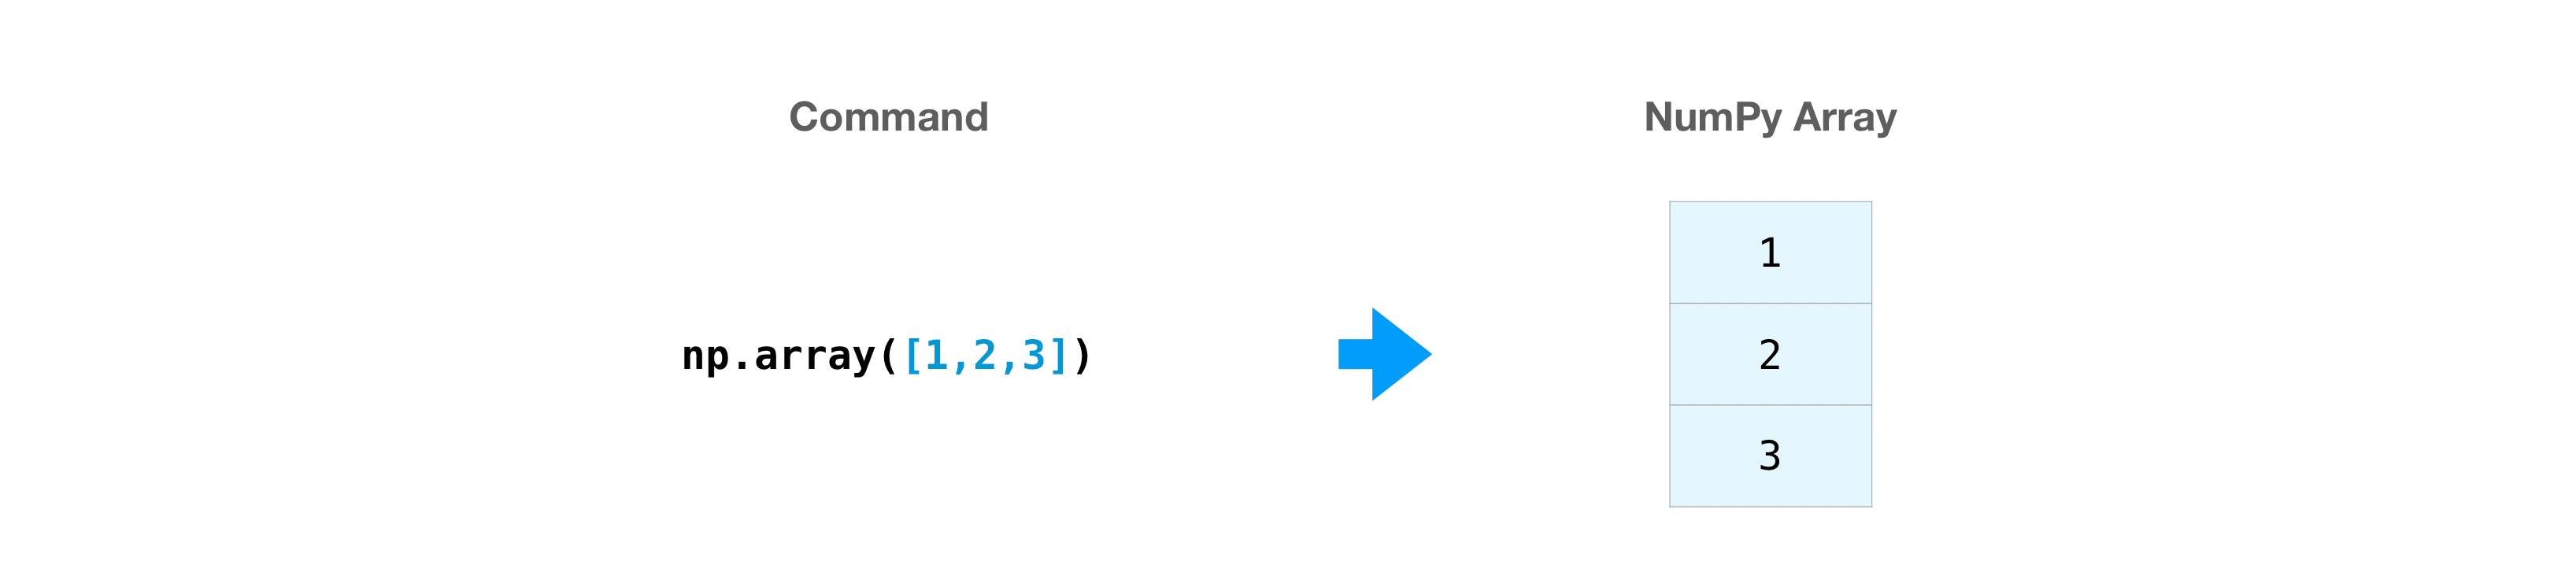

In [3]:
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
a

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

You might occasionally hear an array referred to as a “ndarray,” which is shorthand for “N-dimensional array.” An N-dimensional array is simply an array with any number of dimensions. You might also hear 1-D, or one-dimensional array, 2-D, or two-dimensional array, and so on. The NumPy ndarray class is used to represent both matrices and vectors. A vector is an array with a single dimension (there’s no difference between row and column vectors), while a matrix refers to an array with two dimensions. For 3-D or higher dimensional arrays, the term tensor is also commonly used.

In [14]:
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
a.ndim # number of dimensions (axes)

2

In [15]:
a.shape # the shape of the array

(3, 4)

In [16]:
a.size # the total size in number of elements

12

In [17]:
len(a) # the size of first axes

3

In [19]:
for row in a:
    print(row)

[1 2 3 4]
[5 6 7 8]
[ 9 10 11 12]


In [20]:
a.dtype # The datatype of array in C types

dtype('int64')

We can access the elements in the array using square brackets. When you’re accessing elements, remember that indexing in NumPy starts at 0. That means that if you want to access the first element in your array, you’ll be accessing element “0”.

In [37]:
a

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [71]:
a[3::-1, 3::-1] # slicing (advanced indexing: a[np.array()])

array([[12, 11, 10,  9],
       [ 8,  7,  6,  5],
       [ 4,  3,  2,  1]])

If you start with these arrays:

In [9]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])

You can concatenate them with np.concatenate().

In [10]:
np.concatenate((a, b))

array([1, 2, 3, 4, 5, 6, 7, 8])

Or, if you start with these arrays:

In [77]:
x = np.array([[1, 2], [3, 4]])
y = np.array([[5, 6]])
x.shape, y.T.shape

((2, 2), (2, 1))

You can concatenate them with:

In [79]:
np.concatenate((x, y.T), axis=1)

array([[1, 2, 5],
       [3, 4, 6]])

#### Can you reshape an array?

This section covers arr.reshape()

Yes!

Using arr.reshape() will give a new shape to an array without changing the data. Just remember that when you use the reshape method, the array you want to produce needs to have the same number of elements as the original array. If you start with an array with 12 elements, you’ll need to make sure that your new array also has a total of 12 elements.

If you start with this array:

In [81]:
a = np.arange(6)
a

array([0, 1, 2, 3, 4, 5])

You can use reshape() to reshape your array. For example, you can reshape this array to an array with three rows and two columns:

In [82]:
b = a.reshape(3, 2)

print(b)

[[0 1]
 [2 3]
 [4 5]]


With np.reshape, you can specify a few optional parameters:

In [89]:
np.reshape(a, shape=(1, 6), order='C')

array([[0, 1, 2, 3, 4, 5]])

a is the array to be reshaped.

newshape is the new shape you want. You can specify an integer or a tuple of integers. If you specify an integer, the result will be an array of that length. The shape should be compatible with the original shape.

order: C means to read/write the elements using C-like index order, F means to read/write the elements using Fortran-like index order, A means to read/write the elements in Fortran-like index order if a is Fortran contiguous in memory, C-like order otherwise. (This is an optional parameter and doesn’t need to be specified.)

If you want to learn more about C and Fortran order, you can read more about the internal [organization of NumPy arrays here](https://numpy.org/doc/stable/dev/internals.html#numpy-internals). Essentially, C and Fortran orders have to do with how indices correspond to the order the array is stored in memory. In Fortran, when moving through the elements of a two-dimensional array as it is stored in memory, the first index is the most rapidly varying index. As the first index moves to the next row as it changes, the matrix is stored one column at a time. This is why Fortran is thought of as a Column-major language. In C on the other hand, the last index changes the most rapidly. The matrix is stored by rows, making it a Row-major language. What you do for C or Fortran depends on whether it’s more important to preserve the indexing convention or not reorder the data.

#### How to convert a 1D array into a 2D array (how to add a new axis to an array)

This section covers np.newaxis

You can use np.newaxis to increase the dimensions of your existing array.

Using np.newaxis will increase the dimensions of your array by one dimension when used once. This means that a 1D array will become a 2D array, a 2D array will become a 3D array, and so on.

For example, if you start with this array:

In [96]:
a = np.array([1, 2, 3, 4, 5, 6])

a.shape, np.newaxis

((6,), None)

You can use np.newaxis to add a new axis:

In [105]:
a = a.reshape(3, 2)
a2 = a[np.newaxis, ..., np.newaxis]

a2.shape, ...

((1, 3, 2, 1), Ellipsis)

np.newaxis is implemented as None. You can use None in place of np.newaxis.

In [18]:
print(np.newaxis)

None


You can explicitly convert a 1D array with either a row vector or a column vector using np.newaxis. For example, you can convert a 1D array to a row vector by inserting an axis along the first dimension:

In [19]:
row_vector = a[np.newaxis, :]

row_vector.shape

(1, 6)

Or, for a column vector, you can insert an axis along the second dimension:

In [20]:
col_vector = a[:, np.newaxis]

col_vector.shape

(6, 1)

You can do the inverse operation using `.squeeze()` method which removes the dimensions of size 1. `np.squeeze` takes the axis that need to be squeezed as an arugment. 

In [21]:
print(col_vector.shape)
a_again = col_vector.squeeze(1)
a_again.shape

(6, 1)


(6,)

In [22]:
print(row_vector.shape)
row_vector.squeeze(0).shape

(1, 6)


(6,)

You can also provide a tuple of axis as argument to squeeze. 

In [23]:
col_vector_as_3D_tensor = a[np.newaxis, :, np.newaxis]
print("col_vector_as_3D_tensor.shape=", col_vector_as_3D_tensor.shape)
col_vector_as_3D_tensor.squeeze((0, 2)).shape

col_vector_as_3D_tensor.shape= (1, 6, 1)


(6,)

If you want to squeeze all the axis, you can call squeeze without an argument, although explicit is better than implicit.

In [24]:
col_vector_as_3D_tensor = a[np.newaxis, :, np.newaxis]
print("col_vector_as_3D_tensor.shape=", col_vector_as_3D_tensor.shape)
col_vector_as_3D_tensor.squeeze().shape

col_vector_as_3D_tensor.shape= (1, 6, 1)


(6,)

Find more information about newaxis [here](https://numpy.org/doc/stable/reference/arrays.indexing.html#arrays-indexing)

#### Indexing and slicing

You can index and slice NumPy arrays in the same ways you can slice Python lists.

In [25]:
data = np.array([1, 2, 3])

data[1]

np.int64(2)

In [26]:
data[0:2]

array([1, 2])

In [27]:
data[1:]

array([2, 3])

In [28]:
data[-2:]

array([2, 3])

You can visualize it this way:

![](https://numpy.org/doc/stable/_images/np_indexing.png)

You may want to take a section of your array or specific array elements to use in further analysis or additional operations. To do that, you'll need to subset, slice, and/or index your arrays.

If you want to select values from your array that fulfill certain conditions, it's straightforward with NumPy.

For example, if you start with this array:

In [29]:
a = np.array([[1 , 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])

You can easily print all of the values in the array that are less than 5.

In [30]:
print(a[a < 5])

[1 2 3 4]


You can also select, for example, numbers that are equal to or greater than 5, and use that condition to index an array.

In [150]:
five_up = (a >= 5)
print(a)
print(five_up)
print(a[five_up])

[ 2  1  5  7  4  6  8 14 10  9 18 20 22]
[False False  True  True False  True  True  True  True  True  True  True
  True]
[ 5  7  6  8 14 10  9 18 20 22]


You can select elements that are divisible by 2:

In [32]:
divisible_by_2 = a[a%2==0]

print(divisible_by_2)

[ 2  4  6  8 10 12]


Or you can select elements that satisfy two conditions using the & and | operators:

In [33]:
c = a[(a > 2) & (a < 11)]
print(c)

[ 3  4  5  6  7  8  9 10]


You can also make use of the logical operators & and | in order to return boolean values that specify whether or not the values in an array fulfill a certain condition. This can be useful with arrays that contain names or other categorical values.

In [34]:
five_up = (a > 5) | (a == 5)

print(five_up)

[[False False False False]
 [ True  True  True  True]
 [ True  True  True  True]]


You can also use np.nonzero() to select elements or indices from an array.

Starting with this array:

In [35]:
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])

You can use np.nonzero() to print the indices of elements that are, for example, less than 5:

In [36]:
b = np.nonzero(a < 5)

print(b)

(array([0, 0, 0, 0]), array([0, 1, 2, 3]))


In this example, a tuple of arrays was returned: one for each dimension. The first array represents the row indices where these values are found, and the second array represents the column indices where the values are found.

If you want to generate a list of coordinates where the elements exist, you can zip the arrays, iterate over the list of coordinates, and print them. For example:

In [37]:
list_of_coordinates= list(zip(b[0], b[1]))
for coord in list_of_coordinates:

    print(coord)


(np.int64(0), np.int64(0))
(np.int64(0), np.int64(1))
(np.int64(0), np.int64(2))
(np.int64(0), np.int64(3))


You can also use np.nonzero() to print the elements in an array that are less than 5 with:

In [38]:
print(a[b])

[1 2 3 4]


If the element you’re looking for doesn’t exist in the array, then the returned array of indices will be empty. For example:

In [39]:
not_there = np.nonzero(a == 42)

print(not_there)

(array([], dtype=int64), array([], dtype=int64))


##### Using `Ellipsis` or `...` 

In [40]:
x = np.array([[[1],[2],[3]], [[4],[5],[6]]])

x.shape

(2, 3, 1)

In [41]:
x[1:2]

array([[[4],
        [5],
        [6]]])

`Ellipsis` or `...` expands to the number of : objects needed for the selection tuple to index all dimensions. In most cases, this means that the length of the expanded selection tuple is x.ndim.  There may only be a single ellipsis present.

In [42]:
x[..., 0]

array([[1, 2, 3],
       [4, 5, 6]])

This is equivalent to:

In [43]:
x[:, :, 0]

array([[1, 2, 3],
       [4, 5, 6]])

Each newaxis object in the selection tuple serves to expand the dimensions of the resulting selection by one unit-length dimension. The added dimension is the position of the newaxis object in the selection tuple. newaxis is an alias for None, and None can be used in place of this with the same result. From the above example:

In [44]:
x[:, np.newaxis, :, :].shape

(2, 1, 3, 1)

In [45]:
x[:, None, :, :].shape

(2, 1, 3, 1)

This can be handy to combine two arrays in a way that otherwise would require explicit reshaping operations. For example:

In [46]:
x = np.arange(5)

x[:, np.newaxis] + x[np.newaxis, :]

array([[0, 1, 2, 3, 4],
       [1, 2, 3, 4, 5],
       [2, 3, 4, 5, 6],
       [3, 4, 5, 6, 7],
       [4, 5, 6, 7, 8]])

Learn more about [indexing and slicing here](https://numpy.org/doc/stable/user/quickstart.html#quickstart-indexing-slicing-and-iterating) and [here]().

Read more about using the nonzero function at: [nonzero](https://numpy.org/doc/stable/reference/generated/numpy.nonzero.html#numpy.nonzero).

#### How to create an array from existing data

This section covers slicing and indexing, np.vstack(), np.hstack(), np.hsplit(), .view(), copy()

You can easily create a new array from a section of an existing array.

Let’s say you have this array:

In [47]:
a = np.array([1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

You can create a new array from a section of your array any time by specifying where you want to slice your array.

In [48]:
arr1 = a[3:8]

arr1

array([4, 5, 6, 7, 8])

Here, you grabbed a section of your array from index position 3 through index position 8.

You can also stack two existing arrays, both vertically and horizontally. Let’s say you have two arrays, a1 and a2:

In [49]:
a1 = np.array([[1, 1],

               [2, 2]])

a2 = np.array([[3, 3],

               [4, 4]])

You can stack them vertically with vstack:

In [50]:
np.vstack((a1, a2))

array([[1, 1],
       [2, 2],
       [3, 3],
       [4, 4]])

Or stack them horizontally with hstack:

In [51]:
np.hstack((a1, a2))

array([[1, 1, 3, 3],
       [2, 2, 4, 4]])

You can split an array into several smaller arrays using hsplit. You can specify either the number of equally shaped arrays to return or the columns after which the division should occur.

Let’s say you have this array:

In [52]:
x = np.arange(1, 25).reshape(2, 12)

x

array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]])

If you wanted to split this array into three equally shaped arrays, you would run:

In [53]:
np.hsplit(x, 3)

[array([[ 1,  2,  3,  4],
        [13, 14, 15, 16]]),
 array([[ 5,  6,  7,  8],
        [17, 18, 19, 20]]),
 array([[ 9, 10, 11, 12],
        [21, 22, 23, 24]])]

If you wanted to split your array after the third and fourth column, you’d run:

In [54]:
np.hsplit(x, (3, 4))

[array([[ 1,  2,  3],
        [13, 14, 15]]),
 array([[ 4],
        [16]]),
 array([[ 5,  6,  7,  8,  9, 10, 11, 12],
        [17, 18, 19, 20, 21, 22, 23, 24]])]

Learn more about [stacking and splitting arrays here](https://numpy.org/doc/stable/user/quickstart.html#quickstart-stacking-arrays).

You can use the view method to create a new array object that looks at the same data as the original array (a shallow copy).

Views are an important NumPy concept! NumPy functions, as well as operations like indexing and slicing, will return views whenever possible. This saves memory and is faster (no copy of the data has to be made). However it’s important to be aware of this - modifying data in a view also modifies the original array!

Let’s say you create this array:

In [55]:
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])

Now we create an array b1 by slicing a and modify the first element of b1. This will modify the corresponding element in a as well!

In [56]:
b1 = a[0, :]

b1

array([1, 2, 3, 4])

In [57]:
b1[0] = 99

b1

array([99,  2,  3,  4])

In [58]:
a

array([[99,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

Using the copy method will make a complete copy of the array and its data (a deep copy). To use this on your array, you could run:

In [59]:
b2 = a.copy()

[Learn more about copies and views here](https://numpy.org/doc/stable/user/quickstart.html#quickstart-copies-and-views).

#### Basic array operations

This section covers addition, subtraction, multiplication, division, and more

Once you’ve created your arrays, you can start to work with them. Let’s say, for example, that you’ve created two arrays, one called “data” and one called “ones”

![](https://numpy.org/doc/stable/_images/np_array_dataones.png)

You can add the arrays together with the plus sign.

In [116]:
twos = np.ones(100_000)*2
ones = np.ones(100_000)

In [117]:
%%timeit
twos + ones

124 μs ± 2.27 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [118]:
%%timeit
threes = np.empty(100_000)
for idx, (o, t) in enumerate(zip(ones[:100_000], twos[:100_000])):
    threes[idx] = o + t
    

24 ms ± 846 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [107]:
data = np.array([1, 2])

ones = np.ones(2, dtype=int)

data + ones

array([2, 3])

![](https://numpy.org/doc/stable/_images/np_data_plus_ones.png)

You can, of course, do more than just addition!

In [61]:
data - ones

array([0, 1])

In [62]:
data * data

array([1, 4])

In [63]:
data / data

array([1., 1.])

![](https://numpy.org/doc/stable/_images/np_sub_mult_divide.png)

Basic operations are simple with NumPy. If you want to find the sum of the elements in an array, you’d use sum(). This works for 1D arrays, 2D arrays, and arrays in higher dimensions.

In [130]:
a = np.arange(6).reshape(3,2)
a.shape

(3, 2)

In [132]:
a.sum(axis=0).shape

(2,)

In [123]:
a = np.array([[1, 2, 3, 4]])

a.sum(axis=-1)

array([10])

To add the rows or the columns in a 2D array, you would specify the axis.

If you start with this array:

In [65]:
b = np.array([[1, 1], [2, 2]])

You can sum over the axis of rows with:

In [66]:
b.sum(axis=0)

array([3, 3])

You can sum over the axis of columns with:

In [67]:
b.sum(axis=1)

array([2, 4])

[Learn more about basic operations here](https://numpy.org/doc/stable/user/quickstart.html#quickstart-basic-operations).

#### Broadcasting

There are times when you might want to carry out an operation between an array and a single number (also called an operation between a vector and a scalar) or between arrays of two different sizes. For example, your array (we’ll call it “data”) might contain information about distance in miles but you want to convert the information to kilometers. You can perform this operation with:

In [68]:
data = np.array([1.0, 2.0])

data * 1.6

array([1.6, 3.2])

![](https://numpy.org/doc/stable/_images/np_multiply_broadcasting.png)

NumPy understands that the multiplication should happen with each cell. That concept is called broadcasting. Broadcasting is a mechanism that allows NumPy to perform operations on arrays of different shapes. The dimensions of your array must be compatible, for example, when the dimensions of both arrays are equal or when one of them is 1. If the dimensions are not compatible, you will get a ValueError.

[Learn more about broadcasting here](https://numpy.org/doc/stable/user/basics.broadcasting.html#basics-broadcasting).

#### More useful array operations

This section covers maximum, minimum, sum, mean, product, standard deviation, and more

NumPy also performs aggregation functions. In addition to min, max, and sum, you can easily run mean to get the average, prod to get the result of multiplying the elements together, std to get the standard deviation, and more.

In [69]:
data.max()

np.float64(2.0)

In [70]:
data.min()

np.float64(1.0)

In [71]:
data.sum()

np.float64(3.0)

![](https://numpy.org/doc/stable/_images/np_aggregation.png)

Let’s start with this array, called “a”

In [72]:
a = np.array([[0.45053314, 0.17296777, 0.34376245, 0.5510652],

              [0.54627315, 0.05093587, 0.40067661, 0.55645993],

              [0.12697628, 0.82485143, 0.26590556, 0.56917101]])

It’s very common to want to aggregate along a row or column. By default, every NumPy aggregation function will return the aggregate of the entire array. To find the sum or the minimum of the elements in your array, run:

In [73]:
a.sum()

np.float64(4.8595784)

Or:

In [74]:
a.min()

np.float64(0.05093587)

You can specify on which axis you want the aggregation function to be computed. For example, you can find the minimum value within each column by specifying axis=0.

In [75]:
a.min(axis=0)

array([0.12697628, 0.05093587, 0.26590556, 0.5510652 ])

You can pass Python lists of lists to create a 2-D array (or “matrix”) to represent them in NumPy.

In [76]:
data = np.array([[1, 2], [3, 4], [5, 6]])

data

array([[1, 2],
       [3, 4],
       [5, 6]])

![](https://numpy.org/doc/stable/_images/np_create_matrix.png)

Indexing and slicing operations are useful when you’re manipulating matrices:

In [77]:
data[0, 1]

np.int64(2)

In [78]:
data[1:3]

array([[3, 4],
       [5, 6]])

In [79]:
data[0:2, 0]

array([1, 3])

![](https://numpy.org/doc/stable/_images/np_matrix_indexing.png)

You can aggregate matrices the same way you aggregated vectors:

In [80]:
data.max()

np.int64(6)

In [81]:
data.min()

np.int64(1)

In [82]:
data.sum()

np.int64(21)

![](https://numpy.org/doc/stable/_images/np_matrix_aggregation.png)

You can aggregate all the values in a matrix and you can aggregate them across columns or rows using the axis parameter. To illustrate this point, let’s look at a slightly modified dataset:

In [83]:
data = np.array([[1, 2], [5, 3], [4, 6]])

data

array([[1, 2],
       [5, 3],
       [4, 6]])

In [84]:
data.max(axis=0)

array([5, 6])

In [85]:
data.max(axis=1)

array([2, 5, 6])

![](https://numpy.org/doc/stable/_images/np_matrix_aggregation_row.png)

Once you’ve created your matrices, you can add and multiply them using arithmetic operators if you have two matrices that are the same size.

In [163]:
data = np.array([[1, 2], [3, 4]])
data = np.random.randint(100, size=(3, 4, 5))

ones = np.array([[1, 1], [1, 1]])
ones = np.ones((3, 4, 1))
data.shape,  ones.shape
(data + ones).shape

(3, 4, 5)

![](https://numpy.org/doc/stable/_images/np_matrix_arithmetic.png)

You can do these arithmetic operations on matrices of different sizes, but only if one matrix has only one column or one row. In this case, NumPy will use its broadcast rules for the operation.

In [87]:
data = np.array([[1, 2], [3, 4], [5, 6]])

ones_row = np.array([[1, 1]])

data + ones_row

array([[2, 3],
       [4, 5],
       [6, 7]])

![](https://numpy.org/doc/stable/_images/np_matrix_broadcasting.png)

Be aware that when NumPy prints N-dimensional arrays, the last axis is looped over the fastest while the first axis is the slowest. For instance:

In [88]:
np.ones((4, 3, 2))

array([[[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]]])

There are often instances where we want NumPy to initialize the values of an array. NumPy offers functions like ones() and zeros(), and the random.Generator class for random number generation for that. All you need to do is pass in the number of elements you want it to generate:

In [89]:
np.ones(3)

array([1., 1., 1.])

In [90]:
np.zeros(3)

array([0., 0., 0.])

In [91]:
np.random.random(3) 

array([0.13664111, 0.2747936 , 0.10218492])

![](https://numpy.org/doc/stable/_images/np_ones_zeros_random.png)

You can also use ones(), zeros(), and random() to create a 2D array if you give them a tuple describing the dimensions of the matrix:

In [92]:
np.ones((3, 2))

array([[1., 1.],
       [1., 1.],
       [1., 1.]])

In [93]:
np.zeros((3, 2))

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [94]:
np.random.random((3, 2)) 

array([[0.7716351 , 0.57488137],
       [0.470642  , 0.86307597],
       [0.46416021, 0.85639808]])

![](https://numpy.org/doc/stable/_images/np_ones_zeros_matrix.png)

Read more about creating arrays, filled with 0’s, 1’s, other values or uninitialized, at [array creation routines](https://numpy.org/doc/stable/reference/routines.array-creation.html#routines-array-creation).

#### Generating random numbers

The use of random number generation is an important part of the configuration and evaluation of many numerical and machine learning algorithms. Whether you need to randomly initialize weights in an artificial neural network, split data into random sets, or randomly shuffle your dataset, being able to generate random numbers (actually, repeatable pseudo-random numbers) is essential.

With Generator.integers, you can generate random integers from low (remember that this is inclusive with NumPy) to high (exclusive). You can set endpoint=True to make the high number inclusive.

You can generate a 2 x 4 array of random integers between 0 and 4 with:

In [95]:
np.random.randint(5, size=(2, 4)) 

array([[2, 3, 3, 3],
       [4, 2, 1, 1]])

[Read more about random number generation here](https://numpy.org/doc/stable/reference/random/index.html#numpyrandom).

#### Transposing and reshaping a matrix

This section covers arr.reshape(), arr.transpose(), arr.T

It’s common to need to transpose your matrices. NumPy arrays have the property T that allows you to transpose a matrix.
![](https://numpy.org/doc/stable/_images/np_transposing_reshaping.png)

You may also need to switch the dimensions of a matrix. This can happen when, for example, you have a model that expects a certain input shape that is different from your dataset. This is where the reshape method can be useful. You simply need to pass in the new dimensions that you want for the matrix.

In [96]:
data.reshape(2, 3)

array([[1, 2, 3],
       [4, 5, 6]])

In [97]:
data.reshape(3, 2)

array([[1, 2],
       [3, 4],
       [5, 6]])

![](https://numpy.org/doc/stable/_images/np_reshape.png)

You can also use .transpose() to reverse or change the axes of an array according to the values you specify.

If you start with this array:

In [98]:
arr = np.arange(6).reshape((2, 3))

arr

array([[0, 1, 2],
       [3, 4, 5]])

You can transpose your array with arr.transpose().

In [99]:
arr.transpose()

array([[0, 3],
       [1, 4],
       [2, 5]])

You can also use arr.T:

In [100]:
arr.T

array([[0, 3],
       [1, 4],
       [2, 5]])

Sometimes you want to represent multiple matrices in a single array. Let's say we have two matrices m1 and m2 concatenated in an array as ms

In [101]:
m1 = np.arange(6).reshape(3, 2)
m2 = np.arange(6, 12).reshape(3, 2)
ms = np.stack((m1, m2))
print(ms.shape)
ms

(2, 3, 2)


array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5]],

       [[ 6,  7],
        [ 8,  9],
        [10, 11]]])

To take the transpose of each matrix, m1 and m2, you can use swapaxes or transpose

In [102]:
ms_T = ms.transpose((0, 2, 1))
print(ms_T.shape)
ms_T

(2, 2, 3)


array([[[ 0,  2,  4],
        [ 1,  3,  5]],

       [[ 6,  8, 10],
        [ 7,  9, 11]]])

In [103]:
ms_T = ms.swapaxes(-1, -2)
print(ms_T.shape)
ms_T

(2, 2, 3)


array([[[ 0,  2,  4],
        [ 1,  3,  5]],

       [[ 6,  8, 10],
        [ 7,  9, 11]]])

Note that ms.T will not transpose each matrix instead it will reverse the order of all axes in the array.

In [104]:
ms.T

array([[[ 0,  6],
        [ 2,  8],
        [ 4, 10]],

       [[ 1,  7],
        [ 3,  9],
        [ 5, 11]]])

To learn more about transposing and reshaping arrays, see [transpose](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html#numpy.transpose), [swapaxes](https://numpy.org/doc/stable/reference/generated/numpy.swapaxes.html#numpy.swapaxes) and [reshape](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html#numpy.reshape).


#### Reshaping and flattening multidimensional arrays

This section covers .flatten(), ravel()

There are two popular ways to flatten an array: .flatten() and .ravel(). The primary difference between the two is that the new array created using ravel() is actually a reference to the parent array (i.e., a “view”). This means that any changes to the new array will affect the parent array as well. Since ravel does not create a copy, it’s memory efficient.

If you start with this array:

In [105]:
x = np.array([[1 , 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])

You can use flatten to flatten your array into a 1D array.

In [106]:
x.flatten()


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

When you use flatten, changes to your new array won’t change the parent array.

For example:

In [107]:
a1 = x.flatten()

a1[0] = 99

print(x)  # Original array
print(a1)  # New array

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
[99  2  3  4  5  6  7  8  9 10 11 12]


But when you use ravel, the changes you make to the new array will affect the parent array.

For example:

In [108]:
a2 = x.ravel()

a2[0] = 98

print(x)  # Original array

print(a2)  # New array

[[98  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
[98  2  3  4  5  6  7  8  9 10 11 12]


Read more about flatten at [ndarray.flatten](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.flatten.html#numpy.ndarray.flatten) and ravel at [ravel](https://numpy.org/doc/stable/reference/generated/numpy.ravel.html#numpy.ravel).


#### Working with mathematical formulas

The ease of implementing mathematical formulas that work on arrays is one of the things that make NumPy so widely used in the scientific Python community.

For example, this is the mean square error formula (a central formula used in supervised machine learning models that deal with regression):
![](https://numpy.org/doc/stable/_images/np_MSE_formula.png)

Implementing this formula is simple and straightforward in NumPy:
![](https://numpy.org/doc/stable/_images/np_MSE_implementation.png)

What makes this work so well is that predictions and labels can contain one or a thousand values. They only need to be the same size.

You can visualize it this way:
![](https://numpy.org/doc/stable/_images/np_mse_viz1.png)

In this example, both the predictions and labels vectors contain three values, meaning n has a value of three. After we carry out subtractions the values in the vector are squared. Then NumPy sums the values, and your result is the error value for that prediction and a score for the quality of the model.
![](https://numpy.org/doc/stable/_images/np_mse_viz2.png) ![](https://numpy.org/doc/stable/_images/np_MSE_explanation2.png)

#### Common mathematical operations

1. Scalar-scalar multiplication
$$ f(a, b) = a b $$

In [109]:
a = np.float64(2)
b = np.float64(3)
a * b

np.float64(6.0)

Numpy allows us to multiply many scalars at the same time. 

In [110]:
a = np.array([2, 5]) 
b = np.array([3, 7])
a, b

(array([2, 5]), array([3, 7]))

In [111]:
a * b

array([ 6, 35])

2. Element-wise multiplication of matrices

Sclar-scalar multiplication in numpy is same as element-wise multiplication of  matrices, also known as Hadamard product
$$ f(A, B) = A \odot B $$

$$
\begin{bmatrix}a_{11}&a_{12}&a_{13}&a_{14}\\a_{21}&a_{22}&a_{23}&a_{24}\\a_{31}&a_{32}&a_{33}&a_{34}\end{bmatrix} \circ \begin{bmatrix}b_{11}&b_{12}&b_{13}&b_{14}\\b_{21}&b_{22}&b_{23}&b_{24}\\b_{31}&b_{32}&b_{33}&b_{34}\end{bmatrix}=\begin{bmatrix}a_{11}\,b_{11}&a_{12}\,b_{12}&a_{13}\,b_{13}&a_{14}\,b_{14}\\a_{21}\,b_{21}&a_{22}\,b_{22}&a_{23}\,b_{23}&a_{24}\,b_{24}\\a_{31}\,b_{31}&a_{32}\,b_{32}&a_{33}\,b_{33}&a_{34}\,b_{34}\end{bmatrix} $$

In [112]:
A = np.arange(12).reshape(3, 4)
B = np.arange(12, 24).reshape(3, 4)
A, B

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [113]:
A * B

array([[  0,  13,  28,  45],
       [ 64,  85, 108, 133],
       [160, 189, 220, 253]])

2. Scalar-vector multiplication
$\newcommand{\bfv}{\mathbf{v}}$
$$ f(\alpha, \bfv) = \alpha \bfv $$



In [114]:
alpha = np.float64(3)
v = np.array([2, 3])
alpha, v

(np.float64(3.0), array([2, 3]))

In [115]:
alpha * v

array([6., 9.])

Numpy allows us to multiply a batch of scalars with a batch of vectors at the same time through broadcasting. Let's say you want to multiply three scalars $\alpha_1 = 1, \alpha_2 = 2, \alpha_3 = 3$ with three vectors $\bfv_1 = [2; 3], \bfv_2 = [5; 7],  \bfv_3 = [9; 11]$, respectively. You can combine them in single arrays $\alpha_s = [\alpha_1; \alpha_2; \alpha_3]$ and a matrix of vectors $\bfv_s = \begin{bmatrix} \bfv_1 \\ \bfv_2 \\ \bfv_3 \end{bmatrix}$

In [116]:
alphas = np.array([1, 2, 3])
vs = np.array([[2, 3],
               [5, 7],
               [9, 11]])
print(vs.shape)
alphas, vs

(3, 2)


(array([1, 2, 3]),
 array([[ 2,  3],
        [ 5,  7],
        [ 9, 11]]))

If we simply multiply `alphas` with `vs`, numpy will throw an error:


In [117]:
alphas * vs

ValueError: operands could not be broadcast together with shapes (3,) (3,2) 

We need to carefully choose the axes along which we want to multiply `alphas` with `vs`. Making `alpha.shape = (3, 1)` will do the trick.

In [118]:
alphas[:, np.newaxis] * vs

array([[ 2,  3],
       [10, 14],
       [27, 33]])

3. Vector-vector dot product
$\newcommand{\bfa}{\mathbf{a}}$
$\newcommand{\bfb}{\mathbf{b}}$
$$ f(\bfa, \bfb) = \bfa^\top \bfb $$

In [119]:
a = np.array([2, 3])
b = np.array([5, 7])
a, b

(array([2, 3]), array([5, 7]))

In [120]:
a @ b

np.int64(31)

Note that you do not need `a.T` because `a` is 1-D array and taking its transpose will not do anything.

In [121]:
a.T

array([2, 3])

Look at the rules for [`np.matmul`](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html) which implements the `@` operator.

1. If both arguments are 2-D they are multiplied like conventional matrices.
2. If either argument is N-D, N > 2, it is treated as a stack of matrices residing in the last two indexes and broadcast accordingly.
3. If the first argument is 1-D, it is promoted to a matrix by prepending a 1 to its dimensions. After matrix multiplication the prepended 1 is removed.
4. If the second argument is 1-D, it is promoted to a matrix by appending a 1 to its dimensions. After matrix multiplication the appended 1 is removed.

In this case rules 3 and 4 are in effect.

How can you multiply many vectors together. Let's try to multiply 3 pairs of vectors ($\bfa_1, \bfa_2, \bfa_3$) and (($\bfb_1, \bfb_2, \bfb_3$) using numpy.

In [134]:
_as = np.array([[2, 3], # a_1
                [3, 5], # a_2
                [5, 7]]) # a_3
bs = np.array([[7, 11], # b_1
               [11, 13], # b_2
               [13, 17]]) # b_3
_as.shape, bs.shape

((3, 2), (3, 2))

If we simply use `@` between `_as` and `bs`, then we will get an error.

In [135]:
_as @ bs

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)

We can tranpose `_as`, but that will give us a `(2,2)` array while we only expect `3` scalars (not 4) each one from corresponding vector multiplication between $\bfa_i^\top \bfb_i$. There are multiple ways to accomplish this.

Approach 1: Make the last two dimensions compatible for matrix multiplication, then use `@` with rule 2 of `np.matmul`., Use `np.squeeze` to remove the unnecessary dimensions with size 1.

In [136]:
_as[..., np.newaxis, :].shape, bs[..., np.newaxis].shape

((3, 1, 2), (3, 2, 1))

In [137]:
(_as[..., np.newaxis, :] @ bs[..., np.newaxis])

array([[[ 47]],

       [[ 98]],

       [[184]]])

Approach 2: Take element-wise product and sum over the last axis (which by definition is the vector-vector dot product).

In [126]:
(_as * bs).sum(axis=-1)

array([ 47,  98, 184])

4. Matrix-vector product
$$ f(A, \bfb) = A\bfb $$
Following the vector-vector product example, multiple matrix-vector pairs can be multiplied using the same tricks.

In [127]:
As = np.random.rand(2, 5, 3) # Two (5x3) matrices
bs = np.random.rand(2, 3) # Two (3x1) vectors
As.shape, bs.shape

((2, 5, 3), (2, 3))

Approach 1: Make them compatiable with rule 2 of `np.matmul`

In [128]:
Abprod1 = (As @ bs[..., np.newaxis]).squeeze(-1) # Two (5x1) vectors
Abprod1.shape

(2, 5)

Approach 2: Use element-wise multiplication followed by sum along the right axis.

In [129]:
Abprod2 = (As * bs[..., np.newaxis, :]).sum(axis=-1)
Abprod2.shape
assert np.allclose(Abprod1, Abprod2)

5. Matrix-matrix product

$$ f(A, B) = AB $$

This is straightforward due to the rule 2 of `np.matmul`

In [130]:
As = np.random.rand(2, 5, 3) # Two (5x3) matrices
Bs = np.random.rand(2, 3, 7) # Two (3x7) vectors
As.shape, Bs.shape

((2, 5, 3), (2, 3, 7))

In [131]:
(As @ Bs).shape

(2, 5, 7)

6. Norm/magnitude of a vector
$$ f(\bfv) = \|\bfv\|$$ 


In [132]:
v = np.array([2, 3, 4])
np.linalg.norm(v)

np.float64(5.385164807134504)

Norm of many vectors

In [133]:
vs = np.array([[2, 3, 4], # v_1
               [3, 4, 5]]) # v_2
np.linalg.norm(vs, axis=-1)

array([5.38516481, 7.07106781])

7. Inverse of a matrix

$$ f(A) = A^{-1}$$ 

In [134]:
A = np.array([[1, 2],
              [2, 1]])
np.linalg.inv(A)

array([[-0.33333333,  0.66666667],
       [ 0.66666667, -0.33333333]])

Inverse of many matrices

In [135]:
As = np.array([[[1, 2],
                [2, 1]],
               [[3, 2],
                [2, 3]]])
print(As.shape)
Ainvs = np.linalg.inv(As)
print(Ainvs.shape)

(2, 2, 2)
(2, 2, 2)


#### How to save and load NumPy objects

This section covers np.save, np.savez, np.savetxt, np.load, np.loadtxt

You will, at some point, want to save your arrays to disk and load them back without having to re-run the code. Fortunately, there are several ways to save and load objects with NumPy. The ndarray objects can be saved to and loaded from the disk files with loadtxt and savetxt functions that handle normal text files, load and save functions that handle NumPy binary files with a .npy file extension, and a savez function that handles NumPy files with a .npz file extension.

The .npy and .npz files store data, shape, dtype, and other information required to reconstruct the ndarray in a way that allows the array to be correctly retrieved, even when the file is on another machine with different architecture.

If you want to store a single ndarray object, store it as a .npy file using np.save. If you want to store more than one ndarray object in a single file, save it as a .npz file using np.savez. You can also save several arrays into a single file in compressed npz format with savez_compressed.

It’s easy to save and load and array with np.save(). Just make sure to specify the array you want to save and a file name. For example, if you create this array:

In [136]:
a = np.array([1, 2, 3, 4, 5, 6])

You can save it as “filename.npy” with:

In [137]:
np.save('filename', a)

You can use np.load() to reconstruct your array.

In [138]:
b = np.load('filename.npy')

If you want to check your array, you can run:

In [139]:
print(b)

[1 2 3 4 5 6]


You can save a NumPy array as a plain text file like a .csv or .txt file with np.savetxt.

For example, if you create this array:

In [140]:
csv_arr = np.array([1, 2, 3, 4, 5, 6, 7, 8])

You can easily save it as a .csv file with the name “new_file.csv” like this:

In [141]:
np.savetxt('new_file.csv', csv_arr)

You can quickly and easily load your saved text file using loadtxt():

In [142]:
np.loadtxt('new_file.csv')

array([1., 2., 3., 4., 5., 6., 7., 8.])

The savetxt() and loadtxt() functions accept additional optional parameters such as header, footer, and delimiter. While text files can be easier for sharing, .npy and .npz files are smaller and faster to read. If you need more sophisticated handling of your text file (for example, if you need to work with lines that contain missing values), you will want to use the genfromtxt function.

With savetxt, you can specify headers, footers, comments, and more.

Learn more about [input and output routines here](https://numpy.org/doc/stable/reference/routines.io.html#routines-io).

#### Plotting arrays with Matplotlib

If you need to generate a plot for your values, it’s very simple with Matplotlib.

For example, you may have an array like this one:

In [143]:
a = np.array([2, 1, 5, 7, 4, 6, 8, 14, 10, 9, 18, 20, 22])

If you already have Matplotlib installed, you can import it with:

In [144]:
import matplotlib.pyplot as plt

# If you're using Jupyter Notebook, you may also want to run the following
# line of code to display your code in the notebook:

%matplotlib inline

All you need to do to plot your values is run:

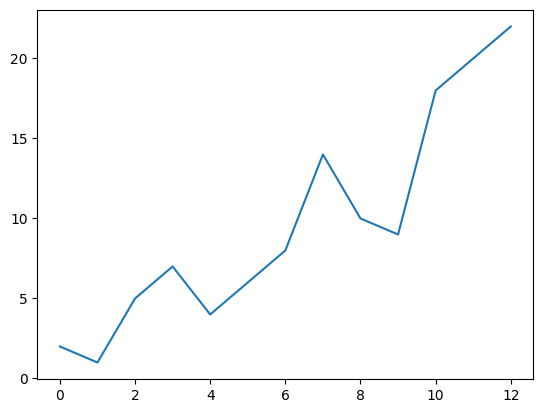

In [145]:
plt.plot(a)

In [146]:
# If you are running from a command line, you may need to do this:
# >>> plt.show()

![](https://numpy.org/doc/stable/_images/matplotlib1.png)

For example, you can plot a 1D array like this:

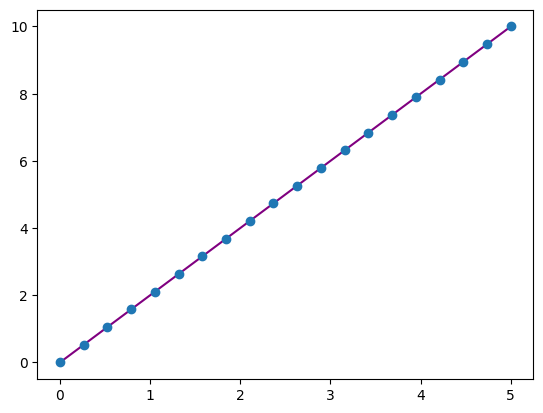

In [147]:
x = np.linspace(0, 5, 20)

y = np.linspace(0, 10, 20)

plt.plot(x, y, 'purple') # line

plt.plot(x, y, 'o')      # dots

![](https://numpy.org/doc/stable/_images/matplotlib2.png)

With Matplotlib, you have access to an enormous number of visualization options.

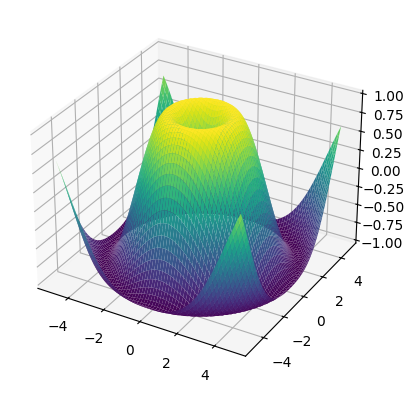

In [148]:
fig = plt.figure()

ax = fig.add_subplot(projection='3d')

X = np.arange(-5, 5, 0.15)

Y = np.arange(-5, 5, 0.15)

X, Y = np.meshgrid(X, Y)

R = np.sqrt(X**2 + Y**2)

Z = np.sin(R)

ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis')

To read more about Matplotlib and what it can do, take a look at the official documentation. For directions regarding installing Matplotlib, see the official installation section.